1. Выберите датасет из открытых источников и исследуйте метаданные датасета(info, describe).  Датасет должен содержать как минимум 5-15 полей и больше 100 записей.
2. Проведите исследование данных с использованием различных графиков- зависимости между разными полями данных, коррелляция других полей с целевой переменной, распределение значении некоторых полей, определение выбросов
3. Проведите предобработку данных(создание новых полей на основе существующих, работа с отсутствующими полями, работа с категориальными переменными, работа с выбросами)
4. Разбейте данные на обучающий и тестовый наборы, проведите масштабирование данных.
5. Обучите модель линейной регрессии, определите важность характеристик(коэффициенты полей).
6. Определите ошибки(MAE, MSE, RMSE, коэффициент детерминации)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score 


In [29]:
df = pd.read_csv('WineQT.csv')
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [31]:
df = df.drop(columns=['Id'])

In [9]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


In [10]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


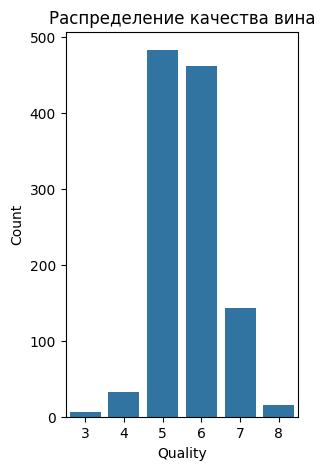

In [11]:
plt.figure(figsize=(3,5))
sns.countplot(x='quality', data=df)
plt.title('Распределение качества вина')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

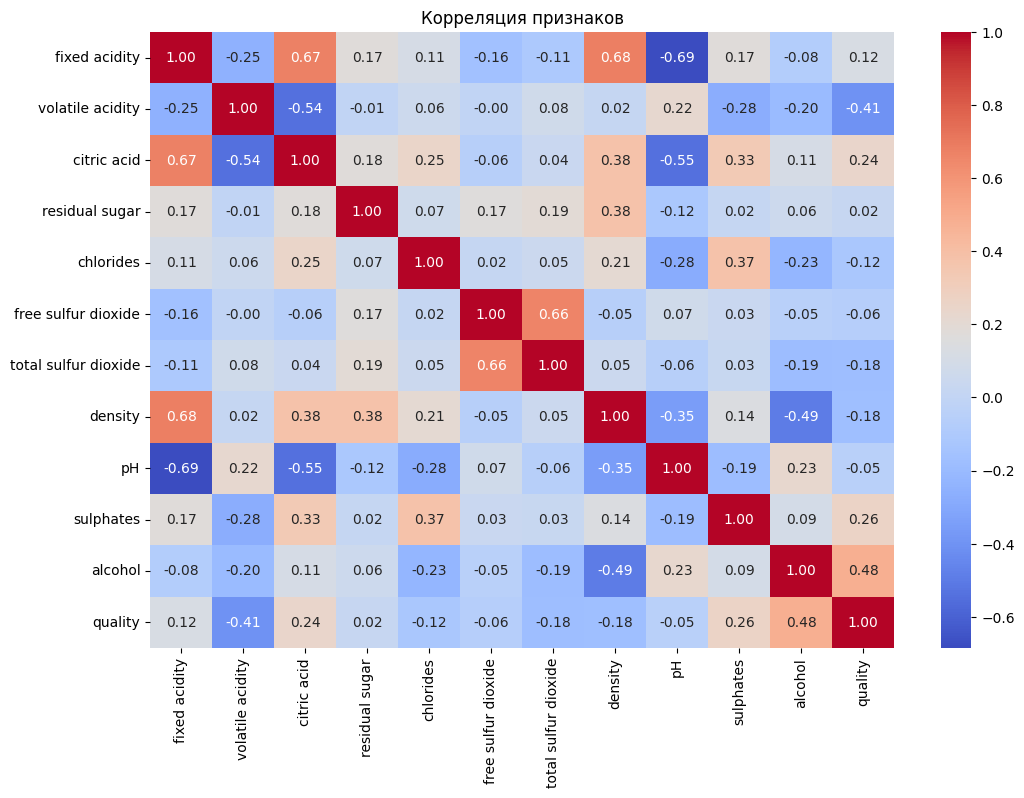

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков')
plt.show()

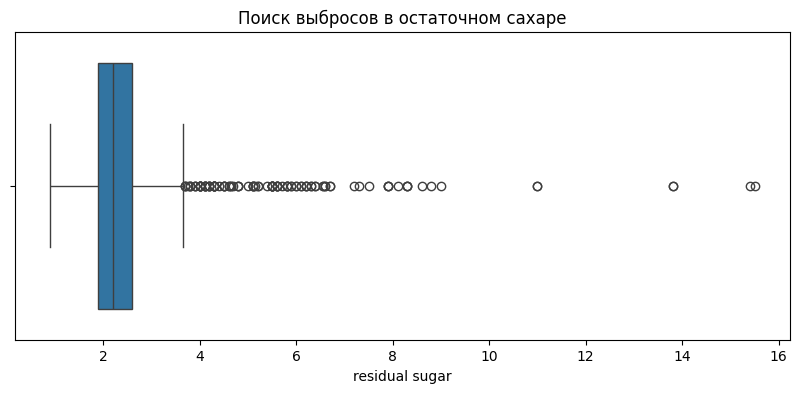

In [13]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['residual sugar'])
plt.title('Поиск выбросов в остаточном сахаре')
plt.show()

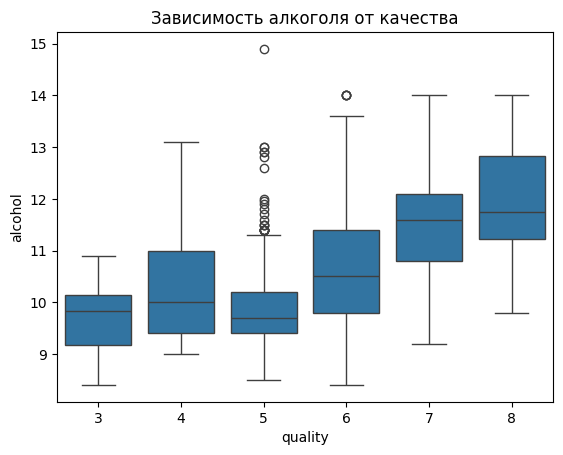

In [14]:
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Зависимость алкоголя от качества')
plt.show()

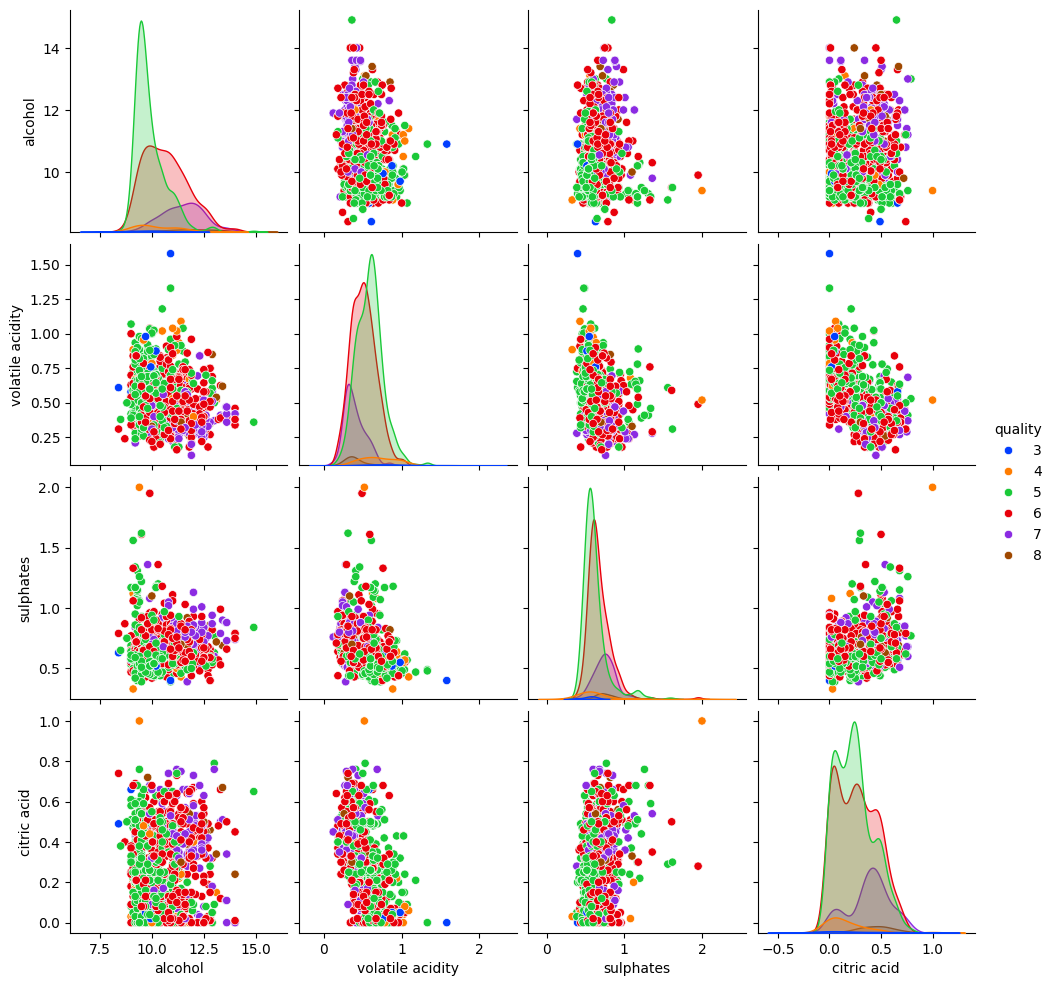

In [15]:
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality']
sns.pairplot(df[top_features], hue='quality', palette='bright')
plt.show()

In [16]:
X = df.drop('quality', axis=1)
y = df['quality']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [18]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(X_train_scaled, y_train)


importance = pd.DataFrame({'Признак': X.columns, 'Влияние': model.coef_})
print(importance.sort_values(by='Влияние', ascending=False))

                 Признак   Влияние
10               alcohol  0.286363
9              sulphates  0.161578
0          fixed acidity  0.087048
5    free sulfur dioxide  0.019244
3         residual sugar  0.005379
8                     pH -0.038087
7                density -0.058650
2            citric acid -0.066082
6   total sulfur dioxide -0.072857
4              chlorides -0.085649
1       volatile acidity -0.239122


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test_scaled)

print(f"Средняя ошибка (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Среднеквадратичная ошибка (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Среднеквадратичная ошибка (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}") 
print(f"Коэффициент детерминации (R2): {r2_score(y_test, y_pred):.2f}")


Средняя ошибка (MAE): 0.48
Среднеквадратичная ошибка (MSE): 0.38
Среднеквадратичная ошибка (RMSE): 0.62
Коэффициент детерминации (R2): 0.32


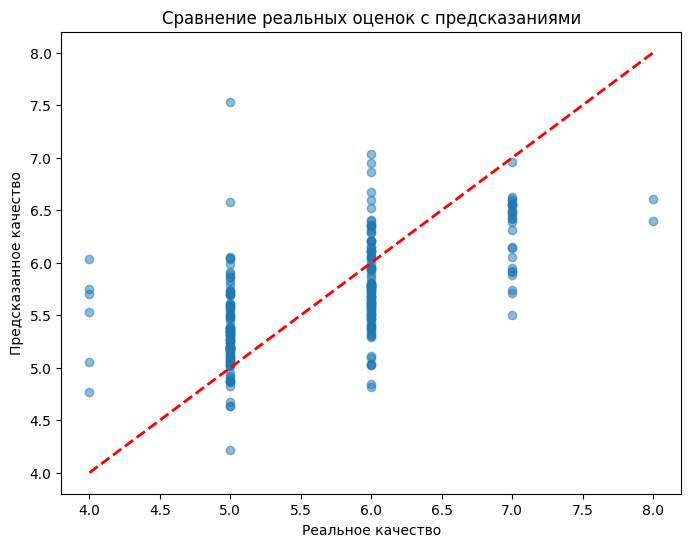

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальное качество')
plt.ylabel('Предсказанное качество')
plt.title('Сравнение реальных оценок с предсказаниями')
plt.show()

RandomForest

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

print(f"RF Средняя ошибка (MAE): {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"RF Коэффициент детерминации (R2): {r2_score(y_test, rf_pred):.2f}")

RF Средняя ошибка (MAE): 0.41
RF Коэффициент детерминации (R2): 0.46


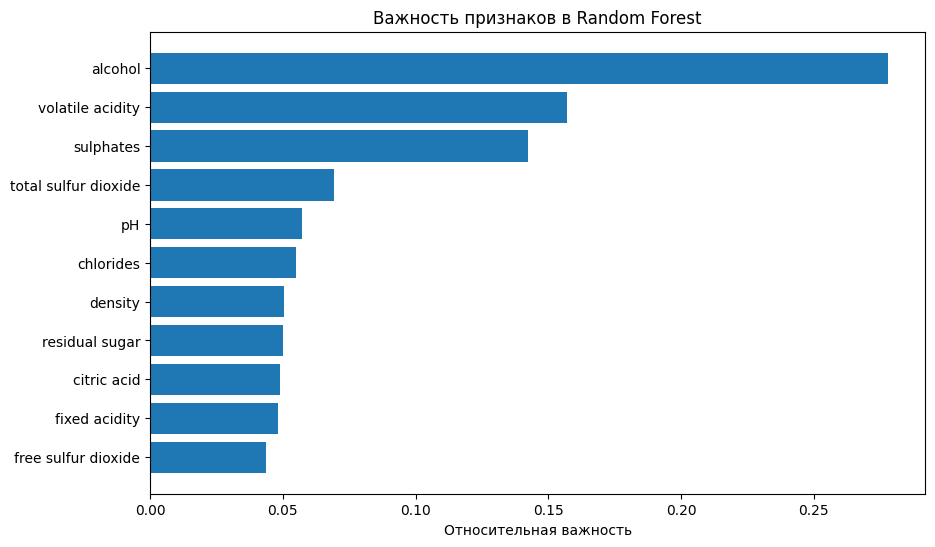

In [22]:
import numpy as np
 
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)
 
plt.figure(figsize=(10, 6))
plt.title('Важность признаков в Random Forest')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Относительная важность')
plt.show()

#  новый признак "Общая кислотность"
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']

In [26]:
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']
 
X = df.drop('quality', axis=1)
y = df['quality']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
model_new = LinearRegression()
model_new.fit(X_train_scaled, y_train)
 
y_pred_new = model_new.predict(X_test_scaled) 

# 7. Выводим результат
print(f"Новый R2: {r2_score(y_test, y_pred_new):.2f}")

Новый R2: 0.32
